In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [25]:
from faker import Faker
faker=Faker()
data=[]
for _ in range(250):
    data.append({
        "Date":faker.date(),
        "open_price":faker.random_int(50,10000),
        "cloe_price":faker.random_int(50,10000),
        "volume":faker.random_int(10,1000)
    })
    df=pd.DataFrame(data)
    df.to_csv("Stock_Market.csv")
    


In [26]:
df.head()

,Date,open_price,cloe_price,volume
0,2015-03-13,4637,1224,445
1,2011-12-15,559,3640,690
2,1974-07-02,4113,3894,487
3,2022-07-27,883,776,880
4,2025-03-14,3905,6708,40


In [27]:
df['daily_return']=df['cloe_price'].pct_change()
df.head()

,Date,open_price,cloe_price,volume,daily_return
0,2015-03-13,4637,1224,445,NaN
1,2011-12-15,559,3640,690,1.973856
2,1974-07-02,4113,3894,487,0.069780
3,2022-07-27,883,776,880,-0.800719
4,2025-03-14,3905,6708,40,7.644330


In [28]:
df['rolling_volatility'] = df['daily_return'].rolling(window=20).std()
df.head()

,Date,open_price,cloe_price,volume,daily_return,rolling_volatility
0,2015-03-13,4637,1224,445,NaN,NaN
1,2011-12-15,559,3640,690,1.973856,NaN
2,1974-07-02,4113,3894,487,0.069780,NaN
3,2022-07-27,883,776,880,-0.800719,NaN
4,2025-03-14,3905,6708,40,7.644330,NaN


In [29]:
last_price = df['cloe_price'].iloc[-1]

simulated_prices = []
price = last_price

for _ in range(30):
    simulated_return = np.random.normal(df['daily_return'].mean(),
                                        df['daily_return'].std())
    price = price * (1 + simulated_return)
    simulated_prices.append(price)
    
simulated_prices

[np.float64(2888.9470951732624),
 np.float64(-8051.685923529298),
 np.float64(-19619.577426792017),
 np.float64(94884.01924940791),
 np.float64(456227.6466946441),
 np.float64(2231120.5464703976),
 np.float64(13848640.341093235),
 np.float64(-20710135.770415038),
 np.float64(-73805443.98473668),
 np.float64(-465102734.79086494),
 np.float64(-2656741455.945723),
 np.float64(-10907111519.531988),
 np.float64(-88761778843.96483),
 np.float64(-529372358290.6477),
 np.float64(-3016204592761.2886),
 np.float64(-13578365709340.074),
 np.float64(-2855217518782.364),
 np.float64(5168126494429.909),
 np.float64(-38867973914338.15),
 np.float64(87939141934889.33),
 np.float64(940094948670594.2),
 np.float64(4974893023881449.0),
 np.float64(2.9954777812132492e+16),
 np.float64(1.5762614026215213e+17),
 np.float64(2.861827390786686e+17),
 np.float64(2.480939864881758e+18),
 np.float64(-3.667245358195055e+18),
 np.float64(-1.082689158155917e+19),
 np.float64(-1.1068046715362129e+20),
 np.float64(-6.

In [30]:
v = np.std(df['daily_return'])
v

np.float64(3.8598662305914306)

In [31]:
a = np.percentile(df['daily_return'], 5)
a

np.float64(nan)

In [32]:
s = df['daily_return'].mean() / df['daily_return'].std()
s

np.float64(0.3209497339338959)

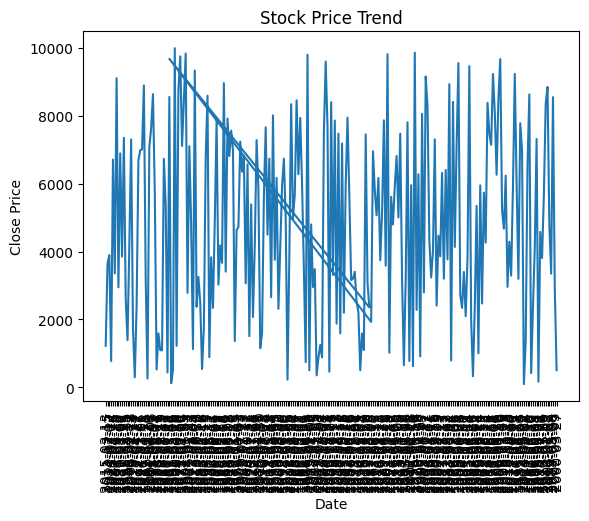

In [33]:
plt.figure()
plt.plot(df['Date'], df['cloe_price'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=90)
plt.show()

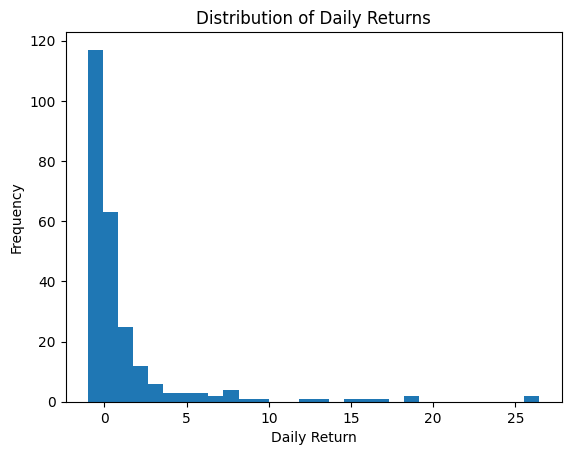

In [34]:
plt.figure()
plt.hist(df['daily_return'].dropna(), bins=30)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()